In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)


In [21]:
data_path = Path("/Users/tsantaloic/Desktop/Projet_05_AIA02/data/raw")

dfs = []

for file in data_path.glob("*.csv"):
    df = pd.read_csv(file)
    df["category"] = file.stem  # sécurité si jamais
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

df_all.shape


(21000, 11)

In [22]:
df_all.head()


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,category
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,"[{'attachment_type': 'IMAGE', 'large_image_url...",B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True,Electronics
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True,Electronics
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True,Electronics
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,1290278495000,18,True,Electronics
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1676601581238,0,True,Electronics


In [23]:
df_all.columns.tolist()

['rating',
 'title',
 'text',
 'images',
 'asin',
 'parent_asin',
 'user_id',
 'timestamp',
 'helpful_vote',
 'verified_purchase',
 'category']

In [24]:
df_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21000 entries, 0 to 20999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             21000 non-null  float64
 1   title              21000 non-null  object 
 2   text               21000 non-null  object 
 3   images             21000 non-null  object 
 4   asin               21000 non-null  object 
 5   parent_asin        21000 non-null  object 
 6   user_id            21000 non-null  object 
 7   timestamp          21000 non-null  int64  
 8   helpful_vote       21000 non-null  int64  
 9   verified_purchase  21000 non-null  bool   
 10  category           21000 non-null  object 
dtypes: bool(1), float64(1), int64(2), object(7)
memory usage: 1.6+ MB


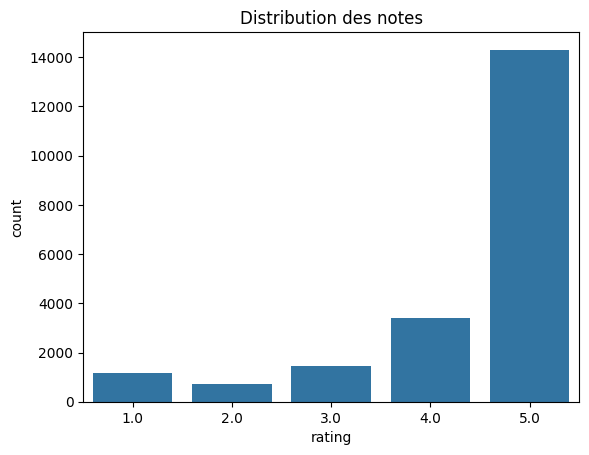

In [25]:
sns.countplot(x="rating", data=df_all)
plt.title("Distribution des notes")
plt.show()


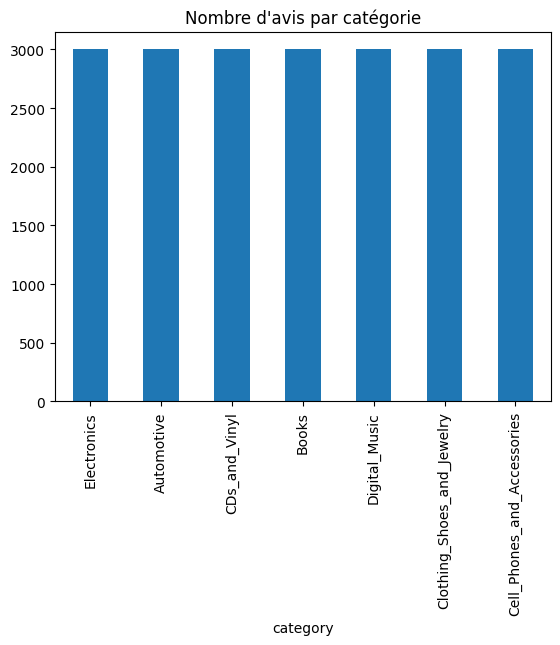

In [26]:
df_all["category"].value_counts().plot(kind="bar")
plt.title("Nombre d'avis par catégorie")
plt.show()


In [27]:
df_all["user_id"].nunique()


3777

In [28]:
df_all["parent_asin"].nunique()


19892

In [29]:
df_all = df_all.drop_duplicates()


In [30]:
df_all.isna().sum().sort_values(ascending=False)


rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
category             0
dtype: int64